In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/leftin
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/dataset
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/dataset/test
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/dataset/test/rottenbanana
/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/dataset/test/freshoranges
/kaggle/input/datasets/leftin/fruit-ripenes

In [2]:
import os
from PIL import Image
from tqdm import tqdm
import random
import matplotlib.pyplot as plt

In [3]:
TRAIN_DATASET = "/kaggle/input/datasets/leftin/fruit-ripeness-unripe-ripe-and-rotten/fruit_ripeness_dataset/archive (1)/dataset/train"

TEST_DATASET = "/kaggle/input/datasets/asadullahprl/fruits-ripeness-classification-dataset/Test"

BASE_OUTPUT = "/kaggle/working/clean_dataset"

# Output folder creation:

In [4]:
classes = ["ripe", "unripe", "overripe"]

for split in ["train", "test"]:
    
    for cls in classes:
        
        os.makedirs(
            os.path.join(BASE_OUTPUT, split, cls),
            exist_ok=True
        )

print("Folders created successfully.")

Folders created successfully.


In [5]:
IMG_SIZE = (224, 224)

In [6]:
def process_and_save_image(src_path, dest_path):

    try:
        img = Image.open(src_path).convert("RGB")

        img = img.resize(IMG_SIZE)

        img.save(dest_path)

        return True

    except Exception as e:

        print(f"Skipped corrupted image: {src_path}")

        return False

# Processing Train data:

In [7]:
train_mapping = {

    "freshbanana": "ripe",
    "freshapples": "ripe",
    "freshoranges": "ripe",

    "unripe banana": "unripe",
    "unripe apple": "unripe",
    "unripe orange": "unripe",

    "rottenbanana": "overripe",
    "rottenapples": "overripe",
    "rottenoranges": "overripe"
}

In [8]:
count = 0

for original_folder, mapped_label in train_mapping.items():

    source_folder = os.path.join(
        TRAIN_DATASET,
        original_folder
    )

    destination_folder = os.path.join(
        BASE_OUTPUT,
        "train",
        mapped_label
    )

    if not os.path.exists(source_folder):
        print(f"Missing folder: {source_folder}")
        continue

    for img_name in tqdm(os.listdir(source_folder)):

        src_img = os.path.join(source_folder, img_name)

        dst_img = os.path.join(
            destination_folder,
            f"train_{count}.jpg"
        )

        success = process_and_save_image(
            src_img,
            dst_img
        )

        if success:
            count += 1

print("Training dataset cleaned.")

100%|██████████| 1595/1595 [00:19<00:00, 80.40it/s]

Training dataset cleaned.


# Processing Test Data:

In [9]:
test_mapping = {

    "Ripe": "ripe",

    "Unripe": "unripe",

    "Overripe": "overripe"
}

In [10]:
count = 0

for original_folder, mapped_label in test_mapping.items():

    source_folder = os.path.join(
        TEST_DATASET,
        original_folder
    )

    destination_folder = os.path.join(
        BASE_OUTPUT,
        "test",
        mapped_label
    )

    if not os.path.exists(source_folder):
        print(f"Missing folder: {source_folder}")
        continue

    for img_name in tqdm(os.listdir(source_folder)):

        src_img = os.path.join(source_folder, img_name)

        dst_img = os.path.join(
            destination_folder,
            f"test_{count}.jpg"
        )

        success = process_and_save_image(
            src_img,
            dst_img
        )

        if success:
            count += 1

print("Test dataset cleaned.")

100%|██████████| 60/60 [00:00<00:00, 126.26it/s]

Test dataset cleaned.


In [11]:
for split in ["train", "test"]:

    print(f"\n{split.upper()} DATASET")

    split_path = os.path.join(BASE_OUTPUT, split)

    for cls in os.listdir(split_path):

        class_path = os.path.join(split_path, cls)

        print(cls, ":", len(os.listdir(class_path)))


TRAIN DATASET
overripe : 6161
unripe : 5316
ripe : 4740

TEST DATASET
overripe : 60
unripe : 60
ripe : 60


# Visual Check:

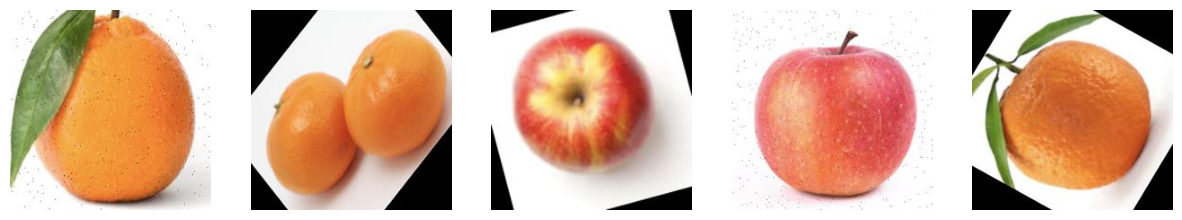

In [12]:
sample_class = "ripe"

sample_folder = os.path.join(
    BASE_OUTPUT,
    "train",
    sample_class
)

sample_images = random.sample(
    os.listdir(sample_folder),
    5
)

plt.figure(figsize=(15,5))

for i, img_name in enumerate(sample_images):

    img = Image.open(
        os.path.join(sample_folder, img_name)
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.show()

# Exporting the Clean Dataset:

In [13]:
!zip -r clean_dataset.zip /kaggle/working/clean_dataset

  adding: kaggle/working/clean_dataset/ (stored 0%)
  adding: kaggle/working/clean_dataset/test/ (stored 0%)
  adding: kaggle/working/clean_dataset/test/overripe/ (stored 0%)
  adding: kaggle/working/clean_dataset/test/overripe/test_159.jpg (deflated 2%)
  adding: kaggle/working/clean_dataset/test/overripe/test_144.jpg (deflated 1%)
  adding: kaggle/working/clean_dataset/test/overripe/test_129.jpg (deflated 1%)
  adding: kaggle/working/clean_dataset/test/overripe/test_160.jpg (deflated 2%)
  adding: kaggle/working/clean_dataset/test/overripe/test_130.jpg (deflated 1%)
  adding: kaggle/working/clean_dataset/test/overripe/test_140.jpg (deflated 1%)
  adding: kaggle/working/clean_dataset/test/overripe/test_153.jpg (deflated 2%)
  adding: kaggle/working/clean_dataset/test/overripe/test_145.jpg (deflated 5%)
  adding: kaggle/working/clean_dataset/test/overripe/test_125.jpg (deflated 3%)
  adding: kaggle/working/clean_dataset/test/overripe/test_158.jpg (deflated 4%)
  adding: kaggle/working/